### Importing packages and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df_v_xx = pd.read_csv("v_xx.txt")
v_xx = df_v_xx["v_xx"].to_numpy()
v_xx_error = df_v_xx["v_xx_error"].to_numpy()
v_xx_r = df_v_xx["v_r"].to_numpy()
v_xx_current = df_v_xx["current"].to_numpy()
print(df_v_xx.dtypes)

df_reversed_v_xx= pd.read_csv("reversed_polarity_v_xx.txt")
reversed_v_xx = df_reversed_v_xx["v_xx"].to_numpy()
reversed_v_xx_error = df_reversed_v_xx["v_xx_error"].to_numpy()
reversed_v_xx_r = df_reversed_v_xx["v_r"].to_numpy()
reversed_v_xx_current = df_reversed_v_xx["current"].to_numpy()
print(v_xx_current)


# v_xx_current = np.divide(v_xx_current, 1e-3) # now in microamps, because originally calculated with mV
# v_xx_volts = np.multiply(v_xx, 1e-3)

v_xx          float64
v_xx_error    float64
v_r           float64
current       float64
dtype: object
[1.85e-07 2.23e-06 4.46e-06 2.05e-05 4.06e-05 6.03e-05 8.04e-05 1.00e-04]


In [9]:
df_v_xy = pd.read_csv("v_xy.txt")
v_xy = df_v_xy["v_xy"].to_numpy()
v_xy_error = df_v_xx["v_xx_error"].to_numpy()
v_xy_r = df_v_xy["v_r"].to_numpy()
v_xy_current = df_v_xy["current"].to_numpy()

print(df_v_xy.dtypes)

df_reversed_v_xy= pd.read_csv("reversed_polarity_v_xy.txt")
reversed_v_xy = df_reversed_v_xy["v_xy"].to_numpy()
reversed_v_xy_error = df_reversed_v_xy["v_xy_error"].to_numpy()
reversed_v_xy_r = df_reversed_v_xy["v_r"].to_numpy()
reversed_v_xy_current = df_reversed_v_xy["current"].to_numpy()

print(v_xy_current)

# v_xy_volts = np.multiply(v_xy, 1e-3)
# v_xy_current = np.divide(v_xy_current, 1e-3) # now in microamps, because originally calculated with mV


v_xy          float64
v_xy_error    float64
v_r           float64
current       float64
dtype: object
[1.81e-07 6.43e-07 2.01e-06 2.01e-05 4.02e-05 6.03e-05 8.04e-05 1.00e-04]


### Are the resistances ohmic?

[-0.2   -0.238 -0.442 -1.89  -3.72  -5.479 -7.204 -9.17 ]


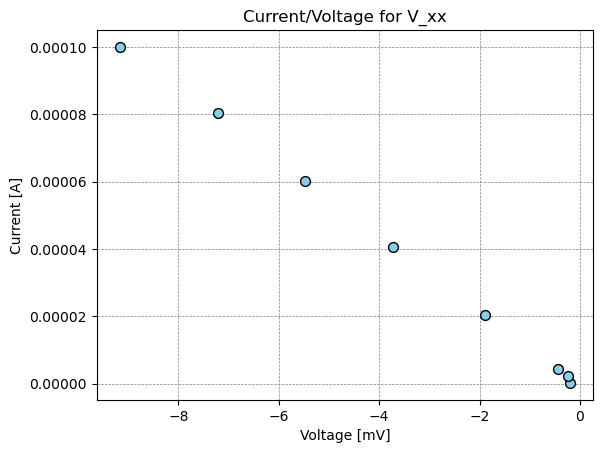

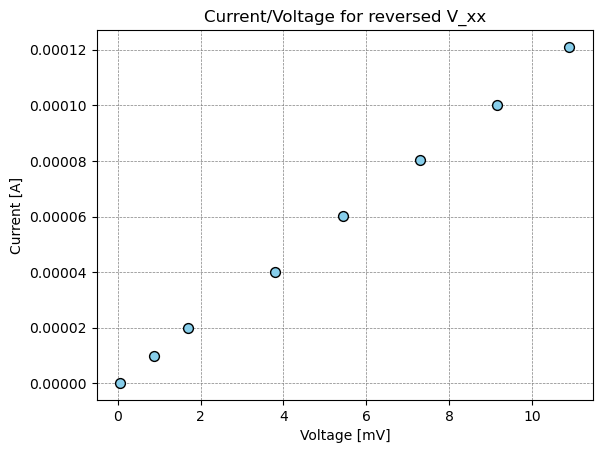

In [24]:
# determine if the resistances are ohmic. 
# voltage on X-axis, current on Y-axis
# V= IR; V/R = I

# Are the resistances actually ohmic?
print(v_xx)
fig, ax = plt.subplots()
ax.scatter(v_xx, v_xx_current, zorder = 20, s = 50, edgecolors = "black", color = "skyblue")
ax.errorbar(v_xx, v_xx_current, xerr = v_xx_error, fmt = "o", c = "black", ms = 2, lw = 0.8)
ax.grid(color='gray', linestyle='--', linewidth=0.5)
ax.set_title("Current/Voltage for V_xx")
ax.set_xlabel("Voltage [mV]")
ax.set_ylabel("Current [A]")
plt.show()

fig, ax = plt.subplots()
ax.scatter(reversed_v_xx, reversed_v_xx_current, zorder = 20, s = 50, edgecolors = "black", color = "skyblue")
ax.errorbar(reversed_v_xx, reversed_v_xx_current, xerr = reversed_v_xx_error, fmt = "o", c = "black", ms = 2, lw = 0.8)
ax.grid(color='gray', linestyle='--', linewidth=0.5)
ax.set_title("Current/Voltage for reversed V_xx")
ax.set_xlabel("Voltage [mV]")
ax.set_ylabel("Current [A]")
plt.show()

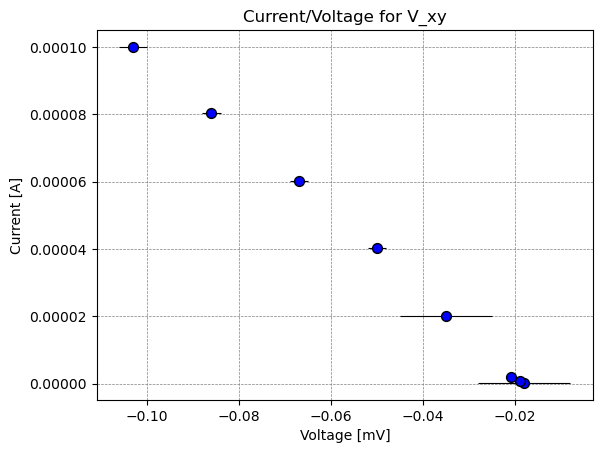

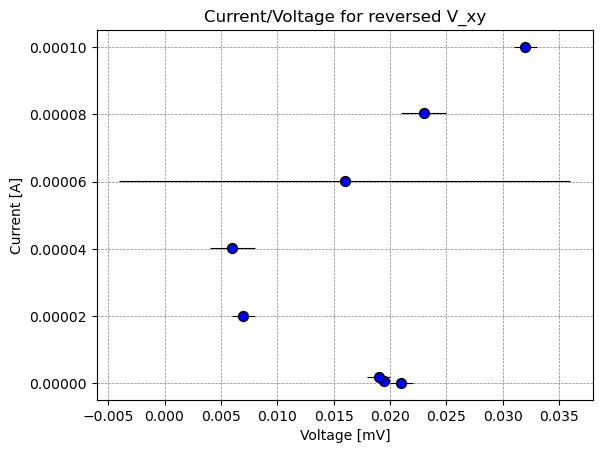

In [26]:
fig, ax = plt.subplots()
ax.scatter(v_xy, v_xy_current, zorder = 20, s = 50, edgecolors = "black", color = "blue")
ax.errorbar(v_xy, v_xy_current, xerr = v_xy_error, fmt = "o", c = "black", ms = 2, lw = 0.8)
ax.grid(color='gray', linestyle='--', linewidth=0.5)
ax.set_title("Current/Voltage for V_xy")
ax.set_xlabel("Voltage [mV]")
ax.set_ylabel("Current [A]")
plt.show()

fig, ax = plt.subplots()
ax.scatter(reversed_v_xy, reversed_v_xy_current, zorder = 20, s = 50, edgecolors = "black", color = "blue")
ax.errorbar(reversed_v_xy, reversed_v_xy_current, xerr = reversed_v_xy_error, fmt = "o", c = "black", ms = 2, lw = 0.8)
ax.grid(color='gray', linestyle='--', linewidth=0.5)
ax.set_title("Current/Voltage for reversed V_xy")
ax.set_xlabel("Voltage [mV]")
ax.set_ylabel("Current [A]")
plt.show()

### Finding thermal voltages and seeing if they depend on current

In [28]:
# "Adding the two voltages can give you a measurement of the thermal voltage (again with a factor of 2 of course)."

thermal_v_xx = np.add(v_xx, reversed_v_xx)
thermal_v_xy = np.add(v_xy, reversed_v_xy)
print("Thermal V_xx: ", thermal_v_xx)
print("Thermal V_xy: ", thermal_v_xy)

Thermal V_xx:  [-0.149  0.642  1.258  1.91   1.73   1.821  1.946  1.73 ]
Thermal V_xy:  [ 0.003   0.0005 -0.002  -0.028  -0.044  -0.051  -0.063  -0.071 ]


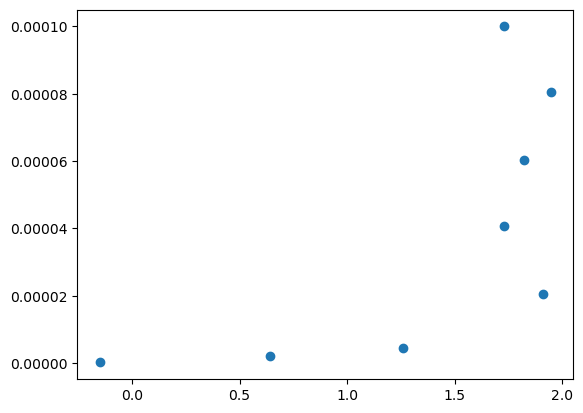

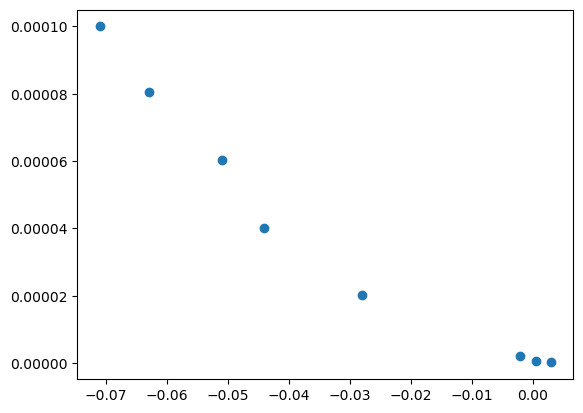

In [30]:
fig, ax = plt.subplots()
ax.scatter(thermal_v_xx, v_xx_current)
plt.show()

fig, ax = plt.subplots()
ax.scatter(thermal_v_xy, v_xy_current)
plt.show()

[  0.181   0.643   2.01   20.1    40.2    60.3    80.4   100.   ]
[-0.018 -0.019 -0.021 -0.035 -0.05  -0.067 -0.086 -0.103]
       chi_sq = 7.01 for 6 d.o.f.
    Slope (m): -8.4513e-01 +/- 1.2e-05 Ohms
Intercept (b): -1.7523e-02 +/- 7.0e-04 mV


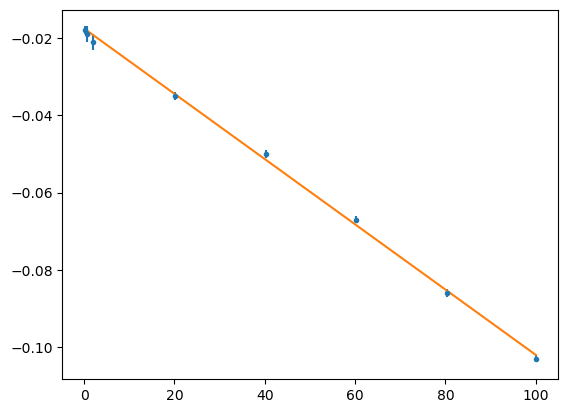

In [ ]:
# want to do a linear least squares fit to determine the 
# Hall coefficient from v_xy and the current. 
# x = v_xy_current, y = v_xy, yerr = v_xy_error
# is current in microamps? is v_xy in mV?

print(v_xy_current)
print(v_xy)

weights = 1.0 / v_xy_error

coefficients, covariance_matrix = np.polyfit(v_xy_current, v_xy, deg=1, w=weights, cov=True)

y_fit = np.polyval(coefficients, v_xy_current)

chi_squared = np.sum(((v_xy - y_fit) / v_xy_error)**2)

uncertainty = np.sqrt(np.diag(covariance_matrix))

print(f"       chi_sq = {chi_squared:.2f} for {len(v_xy_current)-2:.0f} d.o.f.")
print(f"    Slope (m): {1000*coefficients[0]:.4e} +/- {uncertainty[0]:.1e} Ohms")
print(f"Intercept (b): {coefficients[1]:.4e} +/- {uncertainty[1]:.1e} mV")


plt.errorbar(v_xy_current, v_xy, yerr=v_xy_error, fmt='.')
plt.plot(v_xy_current, y_fit)



[ -0.251  -1.118  -2.142  -5.69   -9.17  -12.779 -16.354 -20.07 ]


Text(0, 0.5, 'Current [microamps]')

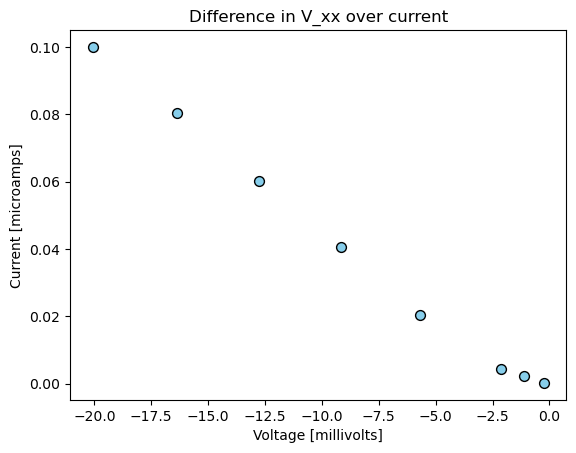

In [80]:
# voltage minus voltage

v_xx_diff = np.subtract(v_xx, v_xx_negative)

print(v_xx_diff)
# removed from v_xx.txt:
# 0.013,0.01,2.60e-3,5.22e-7
# 0.08,0.05,6.00e-3,1.12e-6


fig, ax = plt.subplots()
ax.scatter(v_xx_diff, v_xx_current, color = "skyblue", zorder = 20, s = 50, edgecolors = "black")
ax.set_title("Difference in V_xx over current")
ax.set_xlabel("Voltage [millivolts]")
ax.set_ylabel("Current [microamps]")


# fix later: ax.errorbar(v_xx_diff, v_xx_current, yerr = v_xx_error,  fmt = "o", lw = 0.8)
# plt.scatter(v_xx_diff, v_xx_current)



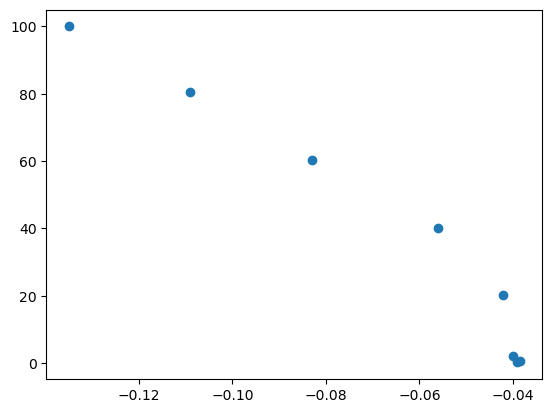

In [60]:
v_xy_diff = np.subtract(v_xy, v_xy_negative)
plt.scatter(v_xy_diff, v_xy_current)